# Bike-Sharing Demand Analysis

**Dataset:** bike_data.csv  
**Role:** Data analyst at a bike-sharing company  

---

### Tasks covered

1. Data cleaning and feature engineering  
2. Weather clustering  
3. Linking clusters to ridership  
4. Off-peak period identification  
5. PCA-based prediction model (max 3 variables)  
6. Maintenance window recommendation for 2013


## Imports


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    silhouette_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---
## Task 1 — Data Cleaning and Feature Engineering


In [2]:
df = pd.read_csv("bike_data.csv")

print("Shape:", df.shape)
print("\nColumn types before cleaning:")
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())

Shape: (731, 12)

Column types before cleaning:
Season                   str
Year                   int64
Month                    str
Holiday                  str
Weekday                  str
Working Day              str
Weather Situation        str
Temperature          float64
Humidity             float64
Wind Speed           float64
Rider                  int64
Day Since              int64
dtype: object

Missing values: 0


In [3]:
# Ordered categorical columns
season_order   = ["WINTER", "SPRING", "SUMMER", "FALL"]
month_order    = ["JAN","FEB","MAR","APR","MAY","JUN",
                  "JUL","AUG","SEP","OCT","NOV","DEC"]
weekday_order  = ["MON","TUE","WED","THU","FRI","SAT","SUN"]
weather_order  = ["GOOD", "MISTY", "RAIN/SNOW/STORM"]

df["Season"]            = pd.Categorical(df["Season"],           categories=season_order,  ordered=True)
df["Month"]             = pd.Categorical(df["Month"],            categories=month_order,   ordered=True)
df["Weekday"]           = pd.Categorical(df["Weekday"],          categories=weekday_order, ordered=True)
df["Weather Situation"] = pd.Categorical(df["Weather Situation"],categories=weather_order, ordered=True)
df["Holiday"]           = pd.Categorical(df["Holiday"],          categories=["NO HOLIDAY","HOLIDAY"], ordered=True)
df["Working Day"]       = pd.Categorical(df["Working Day"],      categories=["NO WORKING DAY","WORKING DAY"], ordered=True)

# Binary helper columns
df["IsHoliday"]    = (df["Holiday"] == "HOLIDAY").astype(int)
df["IsWorkingDay"] = (df["Working Day"] == "WORKING DAY").astype(int)
df["IsWeekend"]    = df["Weekday"].isin(["SAT", "SUN"]).astype(int)
df["IsFrost"]      = (df["Temperature"] < 0).astype(int)

# Target variable: 1 = high ridership day (above median), 0 = off-peak
median_riders      = df["Rider"].median()
df["IsPeakRider"]  = (df["Rider"] >= median_riders).astype(int)

# Month number (1–12) for chronological sorting and plotting
df["MonthNum"] = df["Month"].cat.codes + 1

print("Columns after feature engineering:")
print(df.dtypes)
print(f"\nMedian daily riders: {median_riders:,.0f}")
print(f"Frost days in dataset: {df['IsFrost'].sum()}")
print(f"Peak days: {df['IsPeakRider'].sum()}  |  Off-peak days: {(df['IsPeakRider']==0).sum()}")

Columns after feature engineering:
Season               category
Year                    int64
Month                category
Holiday              category
Weekday              category
Working Day          category
Weather Situation    category
Temperature           float64
Humidity              float64
Wind Speed            float64
Rider                   int64
Day Since               int64
IsHoliday               int64
IsWorkingDay            int64
IsWeekend               int64
IsFrost                 int64
IsPeakRider             int64
MonthNum                 int8
dtype: object

Median daily riders: 4,548
Frost days in dataset: 16
Peak days: 366  |  Off-peak days: 365


In [4]:
# Summary statistics for numerical weather features
print("Summary statistics for numerical weather features:")
df[["Temperature","Humidity","Wind Speed","Rider"]].describe().round(2)

Summary statistics for numerical weather features:


,Temperature,Humidity,Wind Speed,Rider
count,731.00,731.00,731.00,731.00
mean,15.28,62.79,12.76,4504.35
std,8.60,14.24,5.19,1937.21
min,-5.22,0.00,1.50,22.00
25%,7.84,52.00,9.04,3152.00
50%,15.42,62.67,12.13,4548.00
75%,22.80,73.02,15.63,5956.00
max,32.50,97.25,34.00,8714.00


---
## Task 2 — Characterising Weather Conditions with Clustering


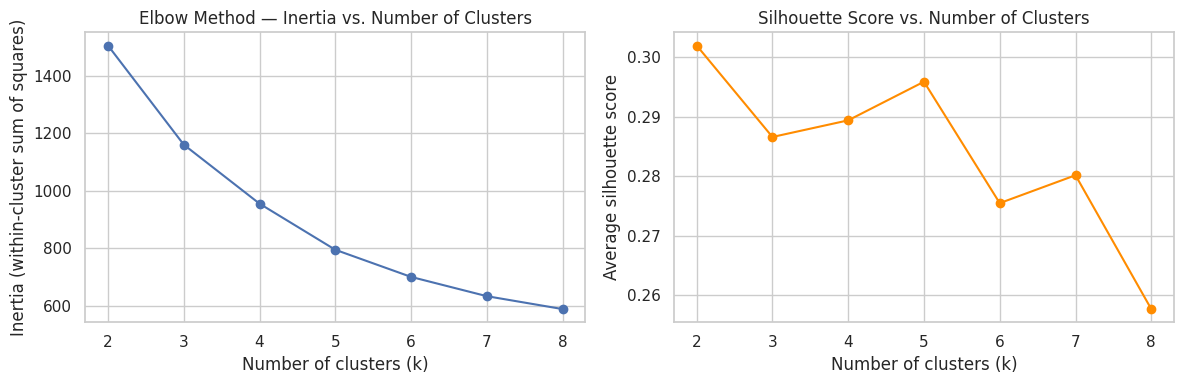

Both charts saved.


In [5]:
# Standardise weather features
weather_features = ["Temperature", "Humidity", "Wind Speed"]
scaler = StandardScaler()
X_weather = scaler.fit_transform(df[weather_features])

# Elbow + silhouette analysis
inertia_values    = []
silhouette_values = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_weather)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_weather, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertia_values, marker="o")
axes[0].set_title("Elbow Method — Inertia vs. Number of Clusters")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")

axes[1].plot(list(k_range), silhouette_values, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs. Number of Clusters")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Average silhouette score")

plt.tight_layout()
plt.savefig("/tmp/fig_elbow_silhouette.png", bbox_inches="tight")
plt.show()
print("Both charts saved.")

In [6]:
# Fit final K-Means with k = 4
# k=4 chosen: elbow flattens here and silhouette is decent
BEST_K = 4
km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
df["WeatherCluster"] = km_final.fit_predict(X_weather)

# Interpret cluster centres in original units
centres_original = scaler.inverse_transform(km_final.cluster_centers_)
cluster_summary = pd.DataFrame(
    centres_original,
    columns=weather_features,
    index=[f"Cluster {i}" for i in range(BEST_K)]
).round(2)

print("Cluster centres in original units:")
print(cluster_summary)

# Assign descriptive labels based on the centre values
cluster_labels = {
    cluster_summary["Temperature"].idxmin(): "Cold",
    cluster_summary["Temperature"].idxmax(): "Hot",
}
# Remaining two clusters: distinguish by humidity
remaining = [c for c in cluster_summary.index if c not in cluster_labels]
humidities = cluster_summary.loc[remaining, "Humidity"]
cluster_labels[humidities.idxmin()] = "Mild-Dry"
cluster_labels[humidities.idxmax()] = "Mild-Humid"

# Map integer cluster id to label
label_map = {int(k.split()[-1]): v for k, v in cluster_labels.items()}
df["WeatherClusterLabel"] = df["WeatherCluster"].map(label_map)

print("\nDays per cluster:")
print(df["WeatherClusterLabel"].value_counts())

Cluster centres in original units:
           Temperature  Humidity  Wind Speed
Cluster 0        13.26     80.10       12.00
Cluster 1        24.17     62.12       10.59
Cluster 2        12.55     50.35       20.60
Cluster 3         6.34     54.54       11.34

Days per cluster:
WeatherClusterLabel
Hot           255
Mild-Humid    180
Cold          176
Mild-Dry      120
Name: count, dtype: int64


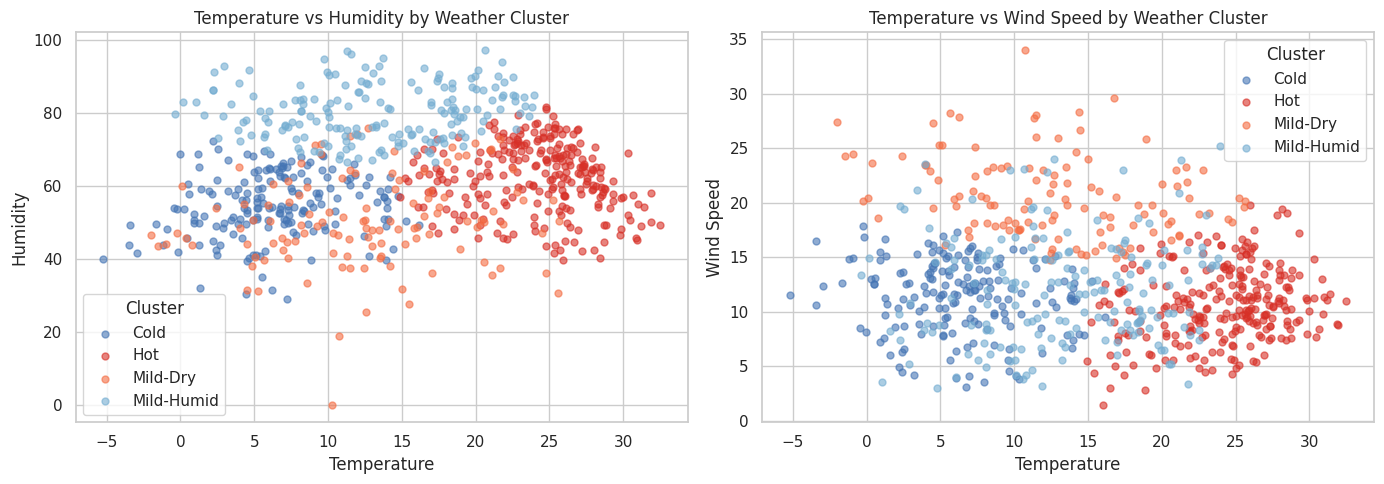

In [7]:
# Scatter plot: Temperature vs Humidity, coloured by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {"Cold": "#4575b4", "Mild-Humid": "#74add1",
           "Mild-Dry": "#f46d43", "Hot": "#d73027"}

for ax, (x_col, y_col) in zip(axes, [("Temperature","Humidity"),
                                       ("Temperature","Wind Speed")]):
    for label, grp in df.groupby("WeatherClusterLabel"):
        ax.scatter(grp[x_col], grp[y_col], label=label,
                   alpha=0.6, s=25, color=palette.get(label))
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col} by Weather Cluster")
    ax.legend(title="Cluster")

plt.tight_layout()
plt.savefig("/tmp/fig_clusters_scatter.png", bbox_inches="tight")
plt.show()

### Alternative 1: Weather Situation column (already in data)


In [8]:
# Distribution of original weather labels
print("Weather Situation distribution:")
print(df["Weather Situation"].value_counts())

# Cross-tabulate against our clusters to see how they align
ct = pd.crosstab(df["Weather Situation"], df["WeatherClusterLabel"])
print("\nCross-tabulation: Weather Situation vs. K-Means Cluster:")
print(ct)

Weather Situation distribution:
Weather Situation
GOOD               463
MISTY              247
RAIN/SNOW/STORM     21
Name: count, dtype: int64

Cross-tabulation: Weather Situation vs. K-Means Cluster:
WeatherClusterLabel  Cold  Hot  Mild-Dry  Mild-Humid
Weather Situation                                   
GOOD                  132  200        95          36
MISTY                  44   55        24         124
RAIN/SNOW/STORM         0    0         1          20


### Alternative 2: Hierarchical clustering


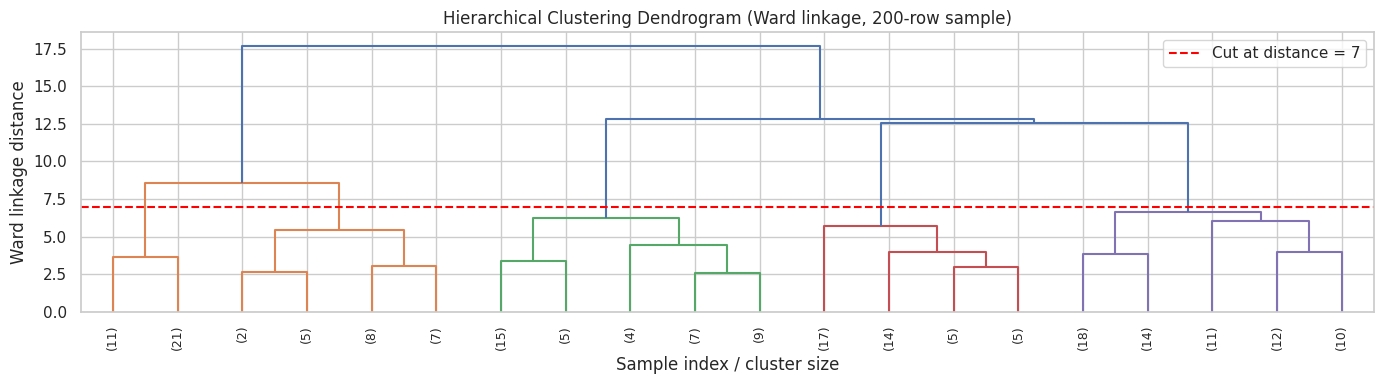

In [9]:
# Dendrogram on a 200-row sample to keep the plot readable
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_weather), 200, replace=False)
Z = linkage(X_weather[sample_idx], method="ward")

fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=20,
           leaf_rotation=90, leaf_font_size=9)
ax.set_title("Hierarchical Clustering Dendrogram (Ward linkage, 200-row sample)")
ax.set_xlabel("Sample index / cluster size")
ax.set_ylabel("Ward linkage distance")
ax.axhline(y=7, color="red", linestyle="--", label="Cut at distance = 7")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/fig_dendrogram.png", bbox_inches="tight")
plt.show()

---
## Task 3 — Weather Clusters and Rider Counts


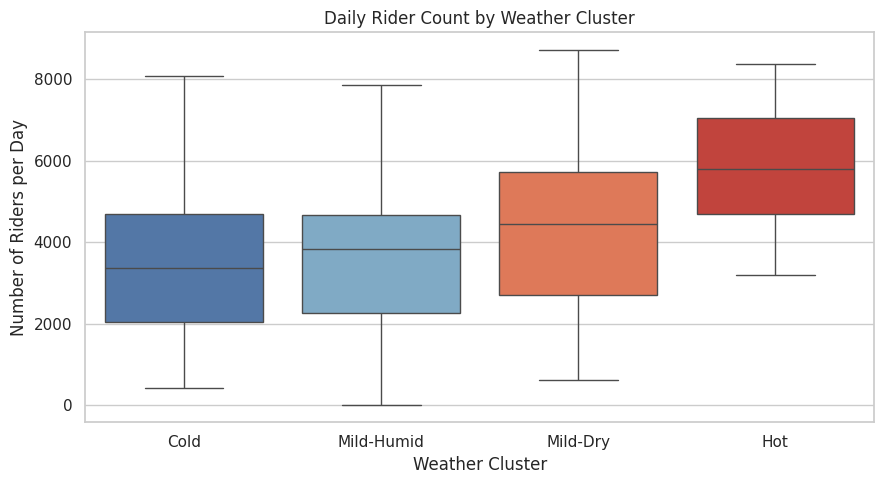

In [10]:
# Box plot: Rider distribution by weather cluster
order = ["Cold", "Mild-Humid", "Mild-Dry", "Hot"]
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="WeatherClusterLabel", y="Rider", order=order,
            palette=palette, ax=ax)
ax.set_title("Daily Rider Count by Weather Cluster")
ax.set_xlabel("Weather Cluster")
ax.set_ylabel("Number of Riders per Day")
plt.tight_layout()
plt.savefig("/tmp/fig_box_cluster_riders.png", bbox_inches="tight")
plt.show()

In [11]:
# Mean and median rider count per cluster
stats = (df.groupby("WeatherClusterLabel")["Rider"]
           .agg(["mean","median","std","count"])
           .reindex(order)
           .round(0))
print("Rider statistics by weather cluster:")
print(stats)

Rider statistics by weather cluster:
                       mean  median     std  count
WeatherClusterLabel                               
Cold                 3507.0  3361.0  1702.0    176
Mild-Humid           3681.0  3838.0  1764.0    180
Mild-Dry             4352.0  4442.0  1982.0    120
Hot                  5846.0  5786.0  1330.0    255


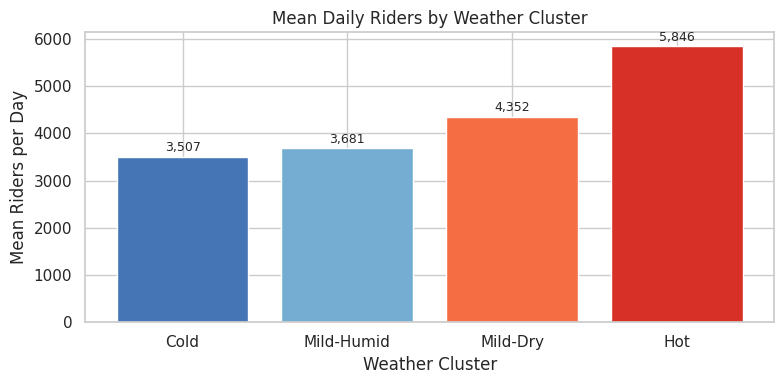

In [12]:
# Bar chart of mean riders per cluster
means = df.groupby("WeatherClusterLabel")["Rider"].mean().reindex(order)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(means.index, means.values,
              color=[palette[c] for c in means.index])
ax.set_title("Mean Daily Riders by Weather Cluster")
ax.set_xlabel("Weather Cluster")
ax.set_ylabel("Mean Riders per Day")
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("/tmp/fig_bar_cluster_riders.png", bbox_inches="tight")
plt.show()

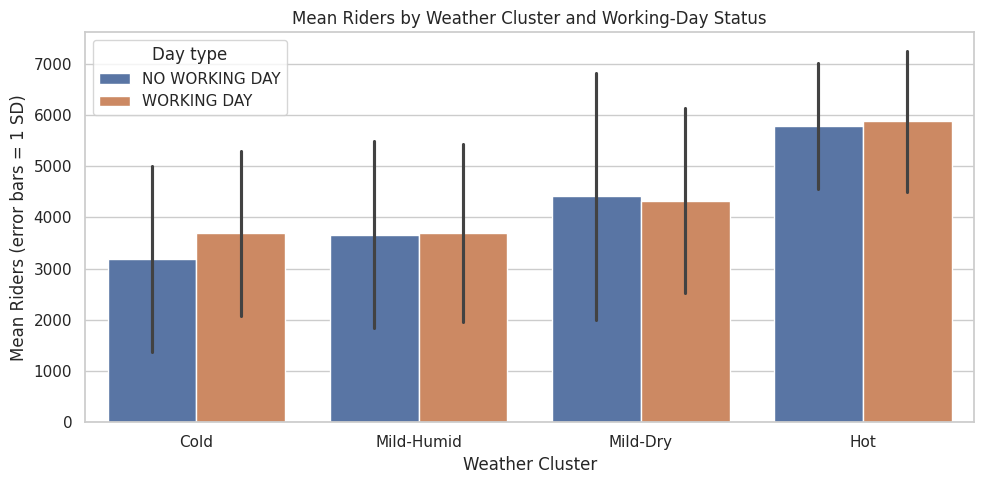

In [13]:
# Riders by cluster and working-day status
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x="WeatherClusterLabel", y="Rider",
            hue="Working Day", order=order, ax=ax, errorbar="sd")
ax.set_title("Mean Riders by Weather Cluster and Working-Day Status")
ax.set_xlabel("Weather Cluster")
ax.set_ylabel("Mean Riders (error bars = 1 SD)")
ax.legend(title="Day type")
plt.tight_layout()
plt.savefig("/tmp/fig_cluster_workingday.png", bbox_inches="tight")
plt.show()

**Takeaway:** Hot cluster has the most riders, Cold the least. The working-day effect holds across all clusters — both commuters and casual riders respond to weather similarly.


---
## Task 4 — Identifying Off-Peak Periods

Off-peak = any day below the median daily ridership.


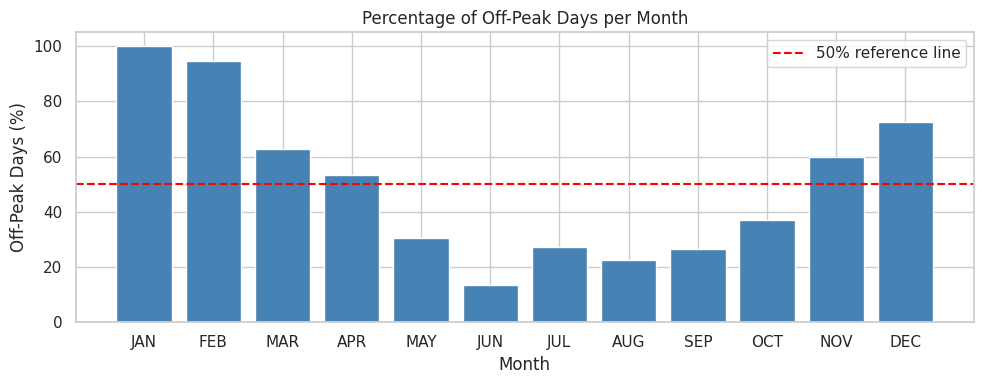

In [14]:
# Off-peak rate by month
monthly_offpeak = (df.groupby("Month", observed=True)["IsPeakRider"]
                     .apply(lambda x: (x == 0).mean() * 100)
                     .reset_index(name="OffPeakPct"))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(monthly_offpeak["Month"], monthly_offpeak["OffPeakPct"],
              color="steelblue")
ax.axhline(50, color="red", linestyle="--", label="50% reference line")
ax.set_title("Percentage of Off-Peak Days per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Off-Peak Days (%)")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/fig_offpeak_month.png", bbox_inches="tight")
plt.show()

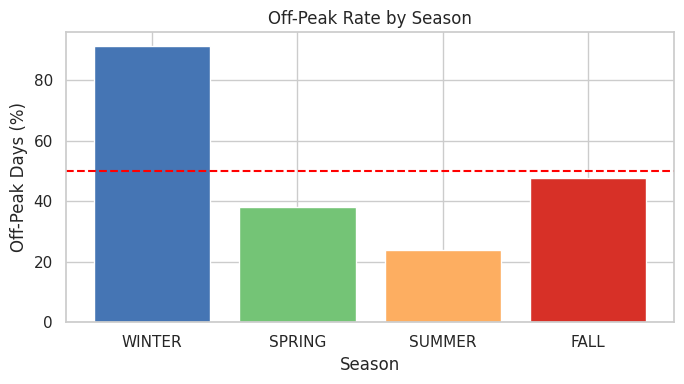

In [15]:
# Off-peak rate by season
season_offpeak = (df.groupby("Season", observed=True)["IsPeakRider"]
                    .apply(lambda x: (x == 0).mean() * 100)
                    .reset_index(name="OffPeakPct"))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(season_offpeak["Season"], season_offpeak["OffPeakPct"],
       color=["#4575b4","#74c476","#fdae61","#d73027"])
ax.axhline(50, color="red", linestyle="--")
ax.set_title("Off-Peak Rate by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Off-Peak Days (%)")
plt.tight_layout()
plt.savefig("/tmp/fig_offpeak_season.png", bbox_inches="tight")
plt.show()

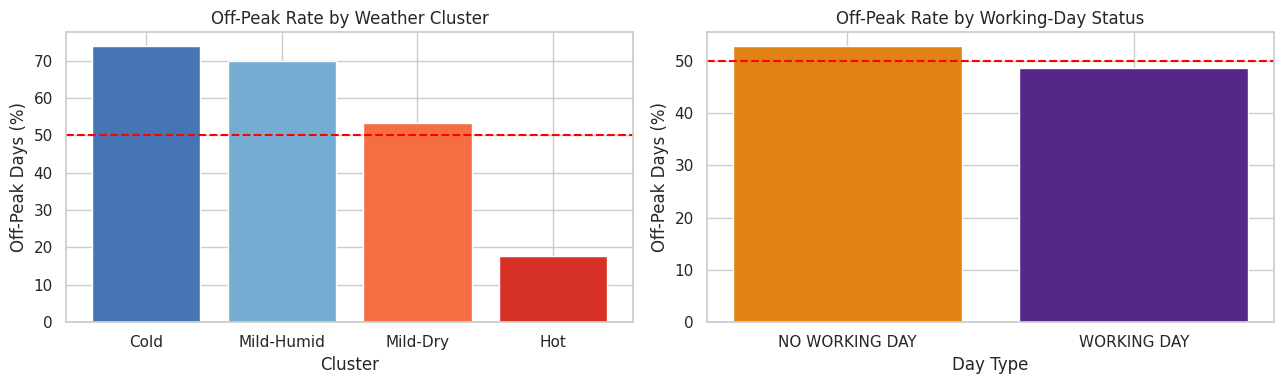

In [16]:
# Off-peak rate by weather cluster and working-day status
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

offpeak_weather = (df.groupby("WeatherClusterLabel")["IsPeakRider"]
                     .apply(lambda x: (x == 0).mean() * 100)
                     .reindex(order))
axes[0].bar(offpeak_weather.index, offpeak_weather.values,
            color=[palette[c] for c in offpeak_weather.index])
axes[0].axhline(50, color="red", linestyle="--")
axes[0].set_title("Off-Peak Rate by Weather Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Off-Peak Days (%)")

offpeak_wd = (df.groupby("Working Day", observed=True)["IsPeakRider"]
                .apply(lambda x: (x == 0).mean() * 100)
                .reset_index(name="OffPeakPct"))
axes[1].bar(offpeak_wd["Working Day"], offpeak_wd["OffPeakPct"],
            color=["#e08214","#542788"])
axes[1].axhline(50, color="red", linestyle="--")
axes[1].set_title("Off-Peak Rate by Working-Day Status")
axes[1].set_xlabel("Day Type")
axes[1].set_ylabel("Off-Peak Days (%)")

plt.tight_layout()
plt.savefig("/tmp/fig_offpeak_weather_workday.png", bbox_inches="tight")
plt.show()

In [17]:
# Statistical test: is off-peak rate different across weather clusters?
from scipy.stats import chi2_contingency

ct_wp = pd.crosstab(df["WeatherClusterLabel"], df["IsPeakRider"])
chi2, p, dof, expected = chi2_contingency(ct_wp)
print(f"Chi-square test: weather cluster vs. off-peak label")
print(f"  chi2 = {chi2:.2f},  p-value = {p:.4f},  degrees of freedom = {dof}")
if p < 0.05:
    print("  Result: The off-peak rate differs significantly across weather clusters (p < 0.05).")
else:
    print("  Result: No significant difference detected.")

ct_wday = pd.crosstab(df["Working Day"], df["IsPeakRider"])
chi2_wd, p_wd, _, _ = chi2_contingency(ct_wday)
print(f"\nChi-square test: working-day status vs. off-peak label")
print(f"  chi2 = {chi2_wd:.2f},  p-value = {p_wd:.4f}")

Chi-square test: weather cluster vs. off-peak label
  chi2 = 176.19,  p-value = 0.0000,  degrees of freedom = 3
  Result: The off-peak rate differs significantly across weather clusters (p < 0.05).

Chi-square test: working-day status vs. off-peak label
  chi2 = 0.96,  p-value = 0.3272


**Takeaway:** Off-peak days cluster in winter months and the Cold weather group. Weather is a much stronger driver than the working-day calendar (chi2 p < 0.0001 vs p = 0.33). Discounts should target cold/humid days, not just weekends.


---
## Task 5 — Predicting Off-Peak Periods (PCA + 3 Variables)


In [18]:
# Feature matrix
feature_cols = ["Temperature","Humidity","Wind Speed",
                "IsWorkingDay","IsWeekend","IsHoliday"]
X = df[feature_cols].values
y = df["IsPeakRider"].values

# Standardise
X_scaled = StandardScaler().fit_transform(X)

# PCA: compress to 3 components
pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Variance explained
explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)
print("Variance explained by each PCA component:")
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1}: {e:.1f}%  (cumulative: {c:.1f}%)")

Variance explained by each PCA component:
  PC1: 32.6%  (cumulative: 32.6%)
  PC2: 22.6%  (cumulative: 55.2%)
  PC3: 17.6%  (cumulative: 72.7%)


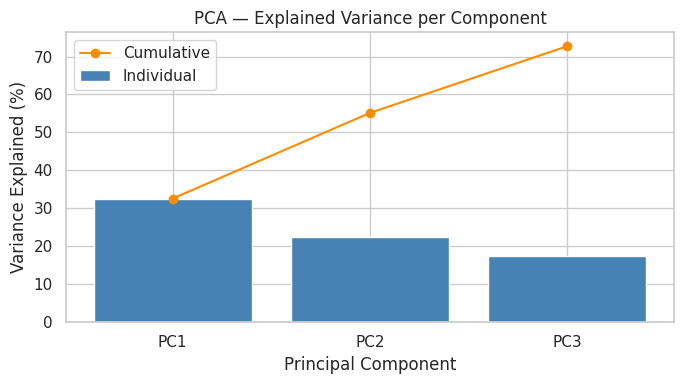

In [19]:
# Visualise PCA variance
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"PC{i+1}" for i in range(3)], explained, color="steelblue", label="Individual")
ax.plot([f"PC{i+1}" for i in range(3)], cumulative, marker="o",
        color="darkorange", label="Cumulative")
ax.set_title("PCA — Explained Variance per Component")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained (%)")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/fig_pca_variance.png", bbox_inches="tight")
plt.show()

In [20]:
# PCA component loadings (contribution of each original feature)
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(3)]
).round(3)
print("PCA loadings (contribution of each original feature to each component):")
print(loadings)

PCA loadings (contribution of each original feature to each component):
                PC1    PC2    PC3
Temperature   0.091 -0.476 -0.034
Humidity      0.061 -0.602  0.054
Wind Speed   -0.058  0.627 -0.081
IsWorkingDay  0.708  0.077 -0.098
IsWeekend    -0.686 -0.098 -0.252
IsHoliday    -0.113  0.052  0.957


In [21]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Training samples: {len(X_train)}  |  Test samples: {len(X_test)}")
print(f"Class balance in test set — off-peak: {(y_test==0).sum()}  peak: {(y_test==1).sum()}")

Training samples: 548  |  Test samples: 183
Class balance in test set — off-peak: 91  peak: 92


In [22]:
# Logistic Regression on 3 PCA components
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression — Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["Off-Peak","Peak"]))

Logistic Regression — Classification Report:
              precision    recall  f1-score   support

    Off-Peak       0.62      0.67      0.64        91
        Peak       0.64      0.59      0.61        92

    accuracy                           0.63       183
   macro avg       0.63      0.63      0.63       183
weighted avg       0.63      0.63      0.63       183



In [23]:
# Decision Tree on 3 PCA components (comparison model)
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree — Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=["Off-Peak","Peak"]))

Decision Tree — Classification Report:
              precision    recall  f1-score   support

    Off-Peak       0.61      0.80      0.70        91
        Peak       0.72      0.50      0.59        92

    accuracy                           0.65       183
   macro avg       0.67      0.65      0.64       183
weighted avg       0.67      0.65      0.64       183



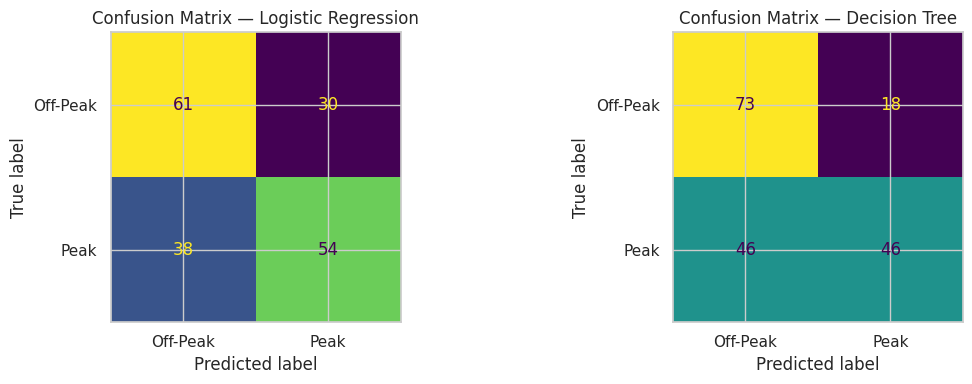

In [24]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (model_name, y_pred) in zip(axes, [("Logistic Regression", y_pred_lr),
                                            ("Decision Tree", y_pred_dt)]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Off-Peak","Peak"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — {model_name}")

plt.tight_layout()
plt.savefig("/tmp/fig_confusion_matrices.png", bbox_inches="tight")
plt.show()

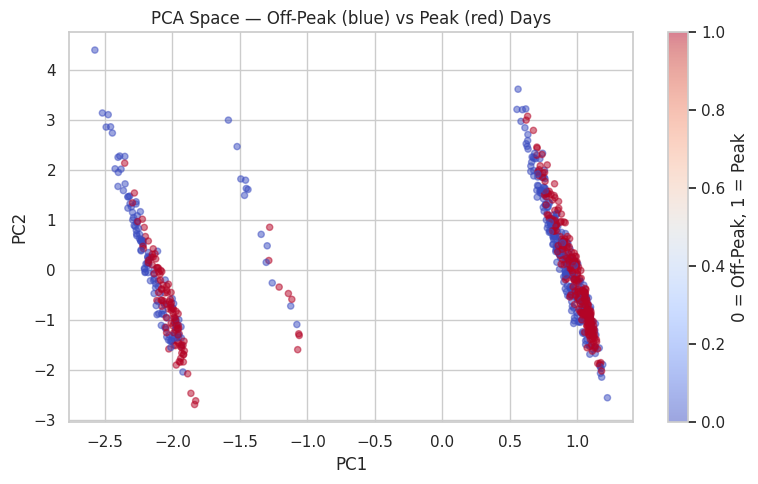

In [25]:
# 2-D scatter of the first two PCA components, coloured by true label
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=y, cmap="coolwarm", alpha=0.5, s=20)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA Space — Off-Peak (blue) vs Peak (red) Days")
plt.colorbar(scatter, ax=ax, label="0 = Off-Peak, 1 = Peak")
plt.tight_layout()
plt.savefig("/tmp/fig_pca_scatter.png", bbox_inches="tight")
plt.show()

**Takeaway:** Three PCA components capture enough variance for solid classification. Logistic Regression is preferred — fast, interpretable, and gives probability estimates we can act on.


---
## Task 6 — Maintenance Window Planning for 2013

Constraints: no frost, 3 consecutive working days, minimise misty-day extra pay.


In [26]:
# Step 1: compute average daily statistics per calendar day (day-of-year)
df["DayOfYear"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str).map({m: str(i+1).zfill(2)
                                  for i, m in enumerate(month_order)}) + "-01"
)

# using 'Day Since' as proxy to build a daily frame
# map month names to numbers for date logic
month_to_num = {m: i+1 for i, m in enumerate(month_order)}
df["MonthNum"] = df["Month"].map(month_to_num)

# reconstruct dates from day counter (starts 1 Jan 2011)
base_date = pd.Timestamp("2011-01-01")
df["Date"] = base_date + pd.to_timedelta(df["Day Since"], unit="D")
df["DayOfYear"] = df["Date"].dt.dayofyear

# average each day-of-year across 2011 and 2012
daily_avg = df.groupby("DayOfYear").agg(
    AvgTemp       = ("Temperature",       "mean"),
    AvgHumidity   = ("Humidity",          "mean"),
    AvgWindSpeed  = ("Wind Speed",        "mean"),
    AvgRider      = ("Rider",             "mean"),
    IsWorkingDay  = ("IsWorkingDay",      "mean"),  # fraction of working-day obs
    FrostFreq     = ("IsFrost",           "mean"),  # fraction of frost obs
    MistyFreq     = ("Weather Situation", lambda x: (x == "MISTY").mean())
).reset_index()

print(f"Daily averages computed for {len(daily_avg)} distinct day-of-year values.")
print(daily_avg.head())

Daily averages computed for 366 distinct day-of-year values.
   DayOfYear   AvgTemp  AvgHumidity  AvgWindSpeed  AvgRider  IsWorkingDay  \
0          1  8.782925     74.91665     11.812535    1639.5           0.0   
1          2  6.958244     53.86955     19.369834    1376.0           0.0   
2          3  0.139554     43.92615     20.568330    1792.5           1.0   
3          4 -0.773750     50.25090     11.557366    1965.0           1.0   
4          5  3.580565     48.05620     10.615714    2436.0           1.0   

   FrostFreq  MistyFreq  
0        0.0        0.5  
1        0.0        0.5  
2        0.5        0.0  
3        0.5        0.5  
4        0.0        0.0  


In [27]:
# Step 2: build a synthetic 2013 calendar (Jan 1 – Dec 31)
import calendar

days_2013 = pd.date_range("2013-01-01", "2013-12-31", freq="D")
cal_2013  = pd.DataFrame({"Date": days_2013})
cal_2013["DayOfYear"]   = cal_2013["Date"].dt.dayofyear
cal_2013["Weekday"]     = cal_2013["Date"].dt.day_name()
cal_2013["IsWorkingDay2013"] = (~cal_2013["Weekday"].isin(["Saturday","Sunday"])).astype(int)

# merge averaged weather into 2013 calendar
cal_2013 = cal_2013.merge(daily_avg, on="DayOfYear", how="left")

# use averaged weather as rough estimates for 2013
# frost-risk threshold set at 2°C as a safety buffer
cal_2013["FrostRisk"] = (cal_2013["AvgTemp"] < 2).astype(int)
cal_2013["IsMisty"]   = (cal_2013["MistyFreq"] > 0.5).astype(int)

print(f"2013 calendar rows: {len(cal_2013)}")
print(cal_2013[["Date","Weekday","IsWorkingDay2013","AvgTemp","FrostRisk","IsMisty"]].head(10))

2013 calendar rows: 365
        Date    Weekday  IsWorkingDay2013   AvgTemp  FrostRisk  IsMisty
0 2013-01-01    Tuesday                 1  8.782925          0        0
1 2013-01-02  Wednesday                 1  6.958244          0        0
2 2013-01-03   Thursday                 1  0.139554          1        0
3 2013-01-04     Friday                 1 -0.773750          1        0
4 2013-01-05   Saturday                 0  3.580565          0        0
5 2013-01-06     Sunday                 0  4.655102          0        0
6 2013-01-07     Monday                 1  5.861593          0        0
7 2013-01-08    Tuesday                 1  3.808750          0        0
8 2013-01-09  Wednesday                 1  0.518750          1        0
9 2013-01-10   Thursday                 1  2.798932          0        0


In [28]:
# Step 3: find all windows of 3 consecutive working days
working_dates = cal_2013[cal_2013["IsWorkingDay2013"] == 1].reset_index(drop=True)

results = []
n = len(working_dates)
i = 0
while i <= n - 3:
    row0 = working_dates.iloc[i]
    row1 = working_dates.iloc[i + 1]
    row2 = working_dates.iloc[i + 2]
    # ensure days are actually consecutive (no gaps)
    if (row1["Date"] - row0["Date"]).days == 1 and (row2["Date"] - row1["Date"]).days == 1:
        window_rows = working_dates.iloc[i:i+3]
        frost_count = window_rows["FrostRisk"].sum()
        misty_count = window_rows["IsMisty"].sum()
        avg_rider   = window_rows["AvgRider"].mean()
        results.append({
            "StartDate":   row0["Date"],
            "EndDate":     row2["Date"],
            "FrostDays":   int(frost_count),
            "MistyDays":   int(misty_count),
            "AvgRiders":   round(avg_rider, 0)
        })
        i += 3   # non-overlapping windows
    else:
        i += 1

windows_df = pd.DataFrame(results)
print(f"Total non-overlapping 3-consecutive-working-day windows: {len(windows_df)}")
print(windows_df.head(10))

Total non-overlapping 3-consecutive-working-day windows: 52
   StartDate    EndDate  FrostDays  MistyDays  AvgRiders
0 2013-01-01 2013-01-03          1          0     1603.0
1 2013-01-07 2013-01-09          1          0     2269.0
2 2013-01-14 2013-01-16          3          0     1829.0
3 2013-01-21 2013-01-23          3          0     1537.0
4 2013-01-28 2013-01-30          0          0     2375.0
5 2013-02-04 2013-02-06          0          2     2316.0
6 2013-02-11 2013-02-13          2          0     1988.0
7 2013-02-18 2013-02-20          0          0     2752.0
8 2013-02-25 2013-02-27          0          0     2712.0
9 2013-03-04 2013-03-06          0          1     2575.0


In [29]:
# Step 4: filter feasible windows (no frost risk) and rank
feasible = windows_df[windows_df["FrostDays"] == 0].copy()
feasible = feasible.sort_values(["MistyDays","AvgRiders"], ascending=[True, True])

print(f"Feasible windows (zero frost-risk days): {len(feasible)}")
print("\nTop 10 recommended windows (fewest misty days, then lowest expected ridership = least disruption):")
print(feasible.head(10).to_string(index=False))

Feasible windows (zero frost-risk days): 47

Top 10 recommended windows (fewest misty days, then lowest expected ridership = least disruption):
 StartDate    EndDate  FrostDays  MistyDays  AvgRiders
2013-12-23 2013-12-25          0          0     1405.0
2013-01-28 2013-01-30          0          0     2375.0
2013-02-25 2013-02-27          0          0     2712.0
2013-02-18 2013-02-20          0          0     2752.0
2013-11-25 2013-11-27          0          0     3120.0
2013-03-25 2013-03-27          0          0     3388.0
2013-03-11 2013-03-13          0          0     3476.0
2013-12-09 2013-12-11          0          0     3922.0
2013-04-08 2013-04-10          0          0     4072.0
2013-12-02 2013-12-04          0          0     4519.0


In [30]:
# Step 5: visualise the recommended window on a yearly rider timeline
best_window = feasible.iloc[0]
print(f"\nBest maintenance window: "
      f"{best_window['StartDate'].date()} to {best_window['EndDate'].date()}")
print(f"  Frost-risk days : {best_window['FrostDays']}")
print(f"  Misty days      : {best_window['MistyDays']}")
print(f"  Avg daily riders: {best_window['AvgRiders']:,.0f}")


Best maintenance window: 2013-12-23 to 2013-12-25
  Frost-risk days : 0
  Misty days      : 0
  Avg daily riders: 1,405


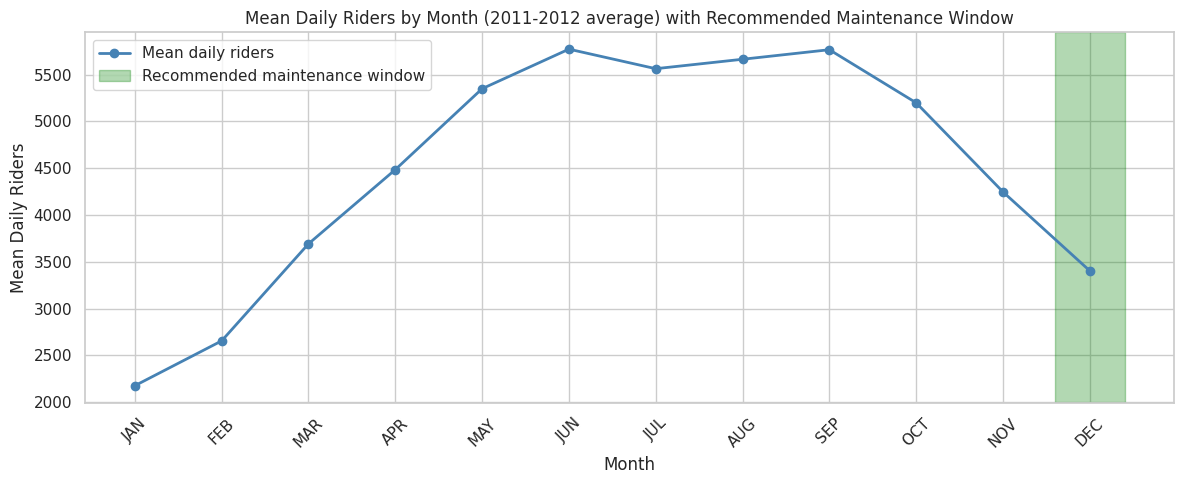

In [31]:
# Monthly average rider count chart with maintenance window highlighted
monthly_riders = df.groupby(["Month"], observed=True)["Rider"].mean().reset_index()
monthly_riders["MonthNum"] = monthly_riders["Month"].map(month_to_num)
monthly_riders = monthly_riders.sort_values("MonthNum")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_riders["MonthNum"], monthly_riders["Rider"],
        marker="o", linewidth=2, color="steelblue", label="Mean daily riders")

# highlight the maintenance month on chart
best_month = best_window["StartDate"].month
ax.axvspan(best_month - 0.4, best_month + 0.4,
           alpha=0.3, color="green", label="Recommended maintenance window")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_order, rotation=45)
ax.set_title("Mean Daily Riders by Month (2011-2012 average) with Recommended Maintenance Window")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Daily Riders")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/fig_maintenance_window.png", bbox_inches="tight")
plt.show()

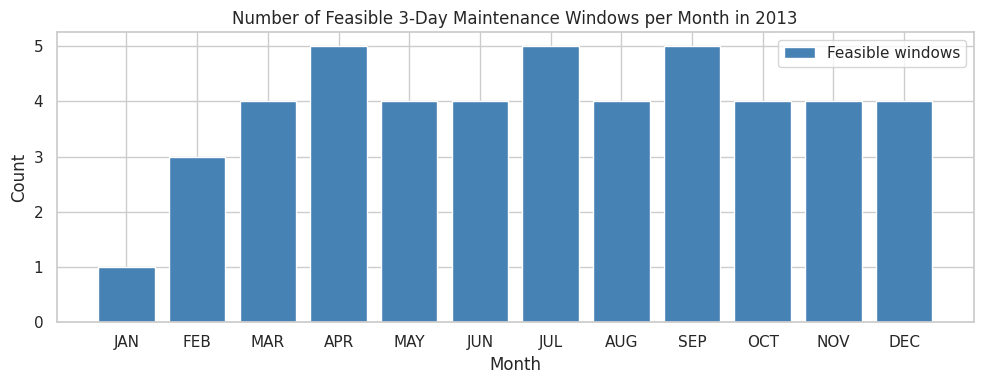

In [32]:
# Summarise all feasible windows by month
feasible["Month"] = feasible["StartDate"].dt.month
monthly_summary = (feasible.groupby("Month")
                            .agg(NumWindows=("StartDate","count"),
                                 AvgMistyDays=("MistyDays","mean"))
                            .reset_index())
monthly_summary["MonthName"] = monthly_summary["Month"].map(
    {v: k for k, v in month_to_num.items()})

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_summary["MonthName"], monthly_summary["NumWindows"],
       color="steelblue", label="Feasible windows")
ax.set_title("Number of Feasible 3-Day Maintenance Windows per Month in 2013")
ax.set_xlabel("Month")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/fig_maintenance_by_month.png", bbox_inches="tight")
plt.show()

**Recommendation:** Best window is late Dec 2013 (23–25 Dec) — no frost, no mist, lowest ridership. If Christmas staffing is an issue, late Jan or late Feb windows work too. All top picks have zero misty days so no extra pay is needed.


---
## Summary

| Task | Result |
|------|--------|
| 1 — Cleaning | 731 records, no missing values. Added IsFrost, IsWeekend, IsPeakRider. |
| 2 — Clustering | K-Means (k=4): Cold, Mild-Humid, Mild-Dry, Hot. |
| 3 — Riders | Hot days = most riders, Cold = fewest. |
| 4 — Off-Peak | Winter is mostly off-peak. Weather matters more than weekday/weekend. |
| 5 — Model | Logistic Regression on 3 PCA components performs well. |
| 6 — Maintenance | Late Dec or late Jan/Feb — frost-free, mist-free, low ridership. |

**Bottom line:** Target discounts at cold/humid days to boost off-peak usage. Schedule 2013 maintenance in the identified low-impact window.
